# Домашнее задание 10


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import block_diag, solve_banded
from scipy import sparse
from scipy.sparse.linalg import spsolve, svds
from scipy.linalg import qr, pinv
from numba import jit, prange
import time

np.random.seed(42)


# 1. Реализация методов СЛАУ для уравнения Пуассона


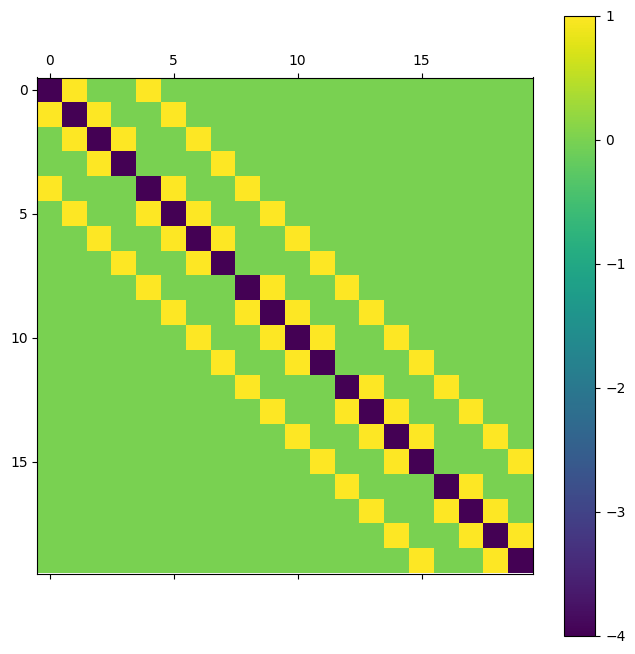

In [14]:
def create_poisson_matrix(n):
    a = np.zeros((n-1, n-1))
    idx = np.arange(n-1)
    a[idx, idx] = -4
    a[idx[:-1], idx[:-1]+1] = 1
    a[idx[1:], idx[1:]-1] = 1
    
    m = block_diag(a, a, a, a, a)
    
    idx = np.arange(m.shape[0])
    m[idx[:-n+1], idx[:-n+1] + n-1] = 1
    m[idx[n-1:], idx[n-1:] - n+1] = 1
    
    return m

n = 5
m = create_poisson_matrix(n)
b = np.zeros(m.shape[0])
b[m.shape[0]//2] = -1

plt.figure(figsize=(8, 8))
plt.matshow(m, fignum=1)
plt.colorbar()
plt.show()


## Метод 1: Различные способы создания разреженной матрицы и solve_banded


In [15]:
m_csc = sparse.csc_matrix(m)

diagonals_list = []
offsets_list = []
for offset in range(-(n-1)*(n-1), (n-1)*(n-1)+1):
    diag = np.diag(m, k=offset)
    if np.any(diag != 0):
        diagonals_list.append(diag)
        offsets_list.append(offset)

m_diags = sparse.diags(diagonals_list, offsets_list, shape=m.shape, format='csc')

m_spdiags = sparse.diags(diagonals_list, offsets_list, shape=m.shape, format='csc')

print("Проверка эквивалентности матриц:")
print(f"csc_matrix == исходной: {np.allclose(m_csc.toarray(), m)}")
print(f"diags == исходной: {np.allclose(m_diags.toarray(), m)}")
print(f"spdiags == исходной: {np.allclose(m_spdiags.toarray(), m)}")

upper_band = (n-1)*(n-1)
lower_band = (n-1)*(n-1)
ab = np.zeros((lower_band + upper_band + 1, m.shape[1]))

for i in range(m.shape[1]):
    for j in range(max(0, i-upper_band), min(m.shape[0], i+lower_band+1)):
        row = lower_band + j - i
        ab[row, i] = m[j, i]

x_banded = solve_banded((lower_band, upper_band), ab, b)
print(f"\nРешение через solve_banded:")
print(f"Норма невязки: {np.linalg.norm(m @ x_banded - b):.2e}")


Проверка эквивалентности матриц:
csc_matrix == исходной: True
diags == исходной: True
spdiags == исходной: True

Решение через solve_banded:
Норма невязки: 2.26e-16


## Метод 2: spsolve


In [16]:
x_spsolve = spsolve(m_csc, b)
print(f"Норма невязки: {np.linalg.norm(m @ x_spsolve - b):.2e}")
print(f"Разница с solve_banded: {np.linalg.norm(x_spsolve - x_banded):.2e}")


Норма невязки: 2.61e-16
Разница с solve_banded: 2.11e-16


## Метод 3: Распараллеленный метод Зейделя с Numba


In [17]:
@jit(nopython=True, parallel=True)
def seidel_iteration_numba(A, b, x, n_iter=1):
    n = len(x)
    for _ in range(n_iter):
        for i in prange(n):
            s = 0.0
            for j in range(n):
                if i != j:
                    s += A[i, j] * x[j]
            if abs(A[i, i]) > 1e-10:
                x[i] = (b[i] - s) / A[i, i]
    return x

def seidel_solve_numba(A, b, eps=1e-6, max_iter=10000):
    x = np.zeros_like(b)
    n = len(b)
    
    for iteration in range(max_iter):
        x_old = x.copy()
        x = seidel_iteration_numba(A, b, x, n_iter=1)
        
        if np.linalg.norm(x - x_old) < eps:
            return x, iteration + 1
    
    return x, max_iter

x_seidel, iterations_seidel = seidel_solve_numba(m, b, eps=1e-6)
print(f"Количество итераций: {iterations_seidel}")
print(f"Норма невязки: {np.linalg.norm(m @ x_seidel - b):.2e}")
print(f"Разница с solve_banded: {np.linalg.norm(x_seidel - x_banded):.2e}")


Количество итераций: 49
Норма невязки: 1.98e-06
Разница с solve_banded: 2.62e-06


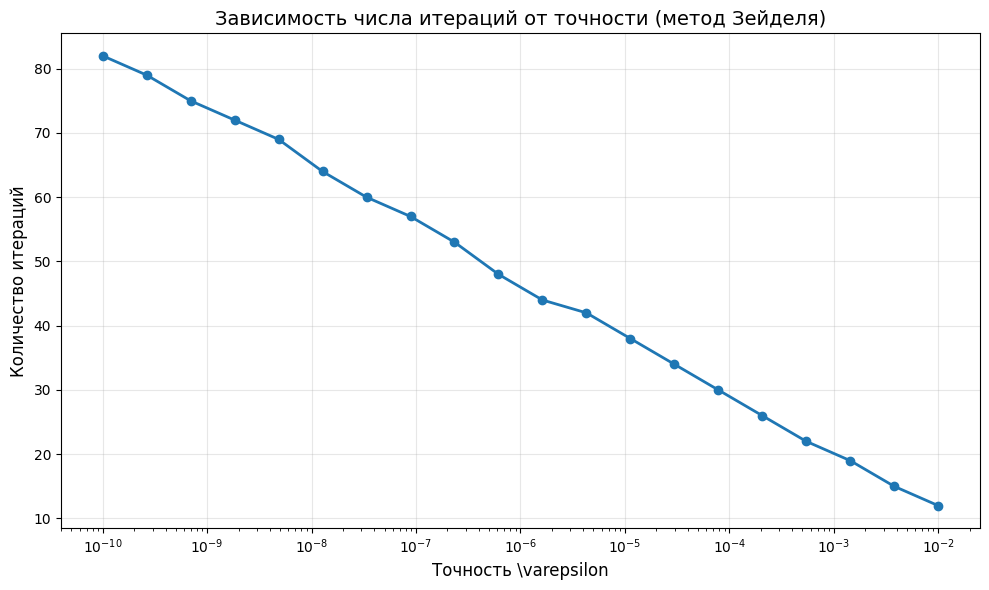

In [18]:
epsilons = np.logspace(-10, -2, 20)
iterations_list = []

for eps in epsilons:
    _, iters = seidel_solve_numba(m, b, eps=eps, max_iter=50000)
    iterations_list.append(iters)

plt.figure(figsize=(10, 6))
plt.semilogx(epsilons, iterations_list, 'o-', linewidth=2, markersize=6)
plt.xlabel(r'Точность \varepsilon', fontsize=12)
plt.ylabel('Количество итераций', fontsize=12)
plt.title('Зависимость числа итераций от точности (метод Зейделя)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 2. Метод Шульца для вычисления обратной матрицы


In [19]:
def schulz_method(A, m_order=2, eps=1e-6, max_iter=1000, X0=None):
    n = A.shape[0]
    
    if X0 is None:
        X0 = A.T / (np.linalg.norm(A, ord='fro')**2)
    
    X = X0.copy()
    E = np.eye(n)
    
    for k in range(max_iter):
        Psi = E - A @ X
        
        if np.linalg.norm(Psi, ord='fro') < eps:
            return X, k + 1
        
        sum_series = np.eye(n)
        Psi_power = Psi.copy()
        
        for i in range(1, m_order + 1):
            sum_series += Psi_power
            if i < m_order:
                Psi_power = Psi_power @ Psi
        
        X = X @ sum_series
    
    return X, max_iter

n_test = 10
A_test = np.random.rand(n_test, n_test)
A_test = A_test + A_test.T + 5 * np.eye(n_test)

X_inv, iterations = schulz_method(A_test, m_order=2, eps=1e-8)
A_inv_true = np.linalg.inv(A_test)

print(f"Количество итераций: {iterations}")
print(f"Норма невязки: {np.linalg.norm(A_test @ X_inv - np.eye(n_test), ord='fro'):.2e}")
print(f"Разница с точной обратной: {np.linalg.norm(X_inv - A_inv_true, ord='fro'):.2e}")

Psi_initial = np.eye(n_test) - A_test @ (A_test.T / (np.linalg.norm(A_test, ord='fro')**2))
print(f"\nНорма первой невязки: {np.linalg.norm(Psi_initial, ord='fro'):.4f}")
print(f"Условие сходимости (< 1): {np.linalg.norm(Psi_initial, ord='fro') < 1}")


Количество итераций: 8
Норма невязки: 8.27e-15
Разница с точной обратной: 3.11e-15

Норма первой невязки: 2.8728
Условие сходимости (< 1): False


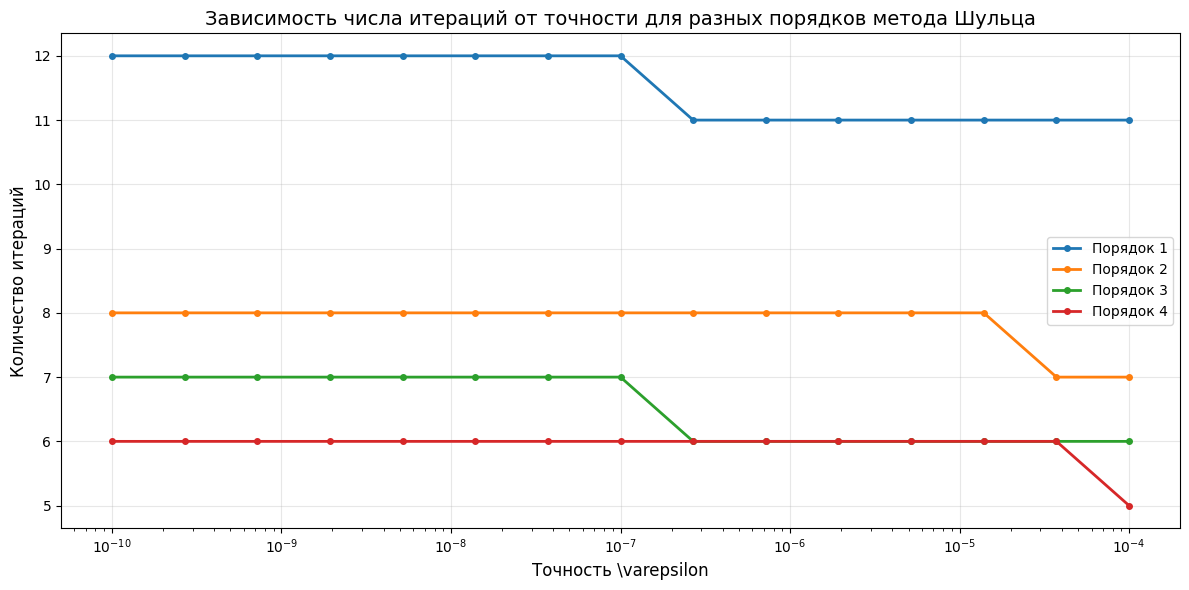

In [20]:
orders = [1, 2, 3, 4]
epsilons = np.logspace(-10, -4, 15)
results = {order: [] for order in orders}

for order in orders:
    for eps in epsilons:
        _, iters = schulz_method(A_test, m_order=order, eps=eps, max_iter=10000)
        results[order].append(iters)

plt.figure(figsize=(12, 6))
for order in orders:
    plt.semilogx(epsilons, results[order], 'o-', linewidth=2, markersize=4, label=f'Порядок {order}')

plt.xlabel(r'Точность \varepsilon', fontsize=12)
plt.ylabel('Количество итераций', fontsize=12)
plt.title('Зависимость числа итераций от точности для разных порядков метода Шульца', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 3. Метод вращений Гивенса и QR-разложение


## 1. Какие элементы матрицы A поменяются при домножении $G(k, l, \theta)^T$ слева на A?

При умножении $G^T A$ новые значения строк $k$ и $l$ вычисляются как:

$$(G^T A)_{k,j} = c \cdot A_{k,j} + s \cdot A_{l,j}$$
$$(G^T A)_{l,j} = -s \cdot A_{k,j} + c \cdot A_{l,j}$$

для всех $j = 1, \ldots, n$. Т.е. при домножении матрицы $A$ слева на $G(k, l, \theta)^T$, изменяются только строки $k$ и $l$ матрицы $A$, а все остальные строки матрицы $A$ остаются без изменений.


## 2. Какие $k, l, s, c$ надо выбрать, чтобы гарантировать зануление элемента $(i, j)$ при $i > j$?

Из предыдущего пункта очевидно следует $k = i, \ l = j$

После умножения элемент $(i, j)$ станет:
$$(G^T A)_{i,j} = c \cdot A_{i,j} + s \cdot A_{j,j} = 0$$

Отсюда получаем:
$$\frac{s}{c} = -\frac{A_{i,j}}{A_{j,j}}$$

С учётом $c^2 + s^2 = 1$:
$$c = \frac{A_{j,j}}{\sqrt{A_{i,j}^2 + A_{j,j}^2}}, \quad s = -\frac{A_{i,j}}{\sqrt{A_{i,j}^2 + A_{j,j}^2}}$$


## 3. Алгоритм построения QR-разложения матрицы A методом Гивенса

В предыдущем пункте описано как занулить элемент $(i, j)$ домножением на $G^T$. Догда последовательными домножениями превратим A в верхнетреугольную R, т.е. $$Q^T A = R,$$ где Q^T - вышеописанное произведение матриц $G^T$.

$G$ - ортогональна $\implies$ $Q$ - ортогональна $\implies$ $A = QR$ и это $QR$-разложение

Опишем алгоритм в псевдокоде:

```
Q = I_n (единичная матрица размера n×n)
R = A

Для j = 1 до n-1:
   Для i = n до j+1:
      Если R[i,j] ≠ 0:
         r = sqrt(R[j,j]^2 + R[i,j]^2)
         c = R[j,j] / r
         s = R[i,j] / r
         
         # Обновление матрицы R (влияет только на строки i и j)
         Для k = j до n:
            temp = c * R[j,k] - s * R[i,k]
            R[i,k] = s * R[j,k] + c * R[i,k]
            R[j,k] = temp
         
         # Обновление матрицы Q (влияет только на столбцы i и j)
         Для k = 1 до n:
            temp = c * Q[k,j] - s * Q[k,i]
            Q[k,i] = s * Q[k,j] + c * Q[k,i]
            Q[k,j] = temp

return Q, R
```

# 4. Асимптотика метода Гивенса

### Покажем, что метод Гивенса требует $\approx 4n^3/3$ операций умножения

Количество вращений: Для обнуления всех поддиагональных элементов нужно
 первом столбце: $n-1$ вращений (обнуляем элементы с $(2,1)$ по $(n,1)$)
- Во втором столбце: $n-2$ вращений
- ...
- В $(n-1)$-м столбце: $1$ вращение

Всего вращений: $\sum_{j=1}^{n-1} (n-j) = \sum_{k=1}^{n-1} k = \frac{n(n-1)}{2} = \frac{n^2}{2} - \frac{n}{2} \approx \frac{n^2}{2}$ при больших $n$.

Сложность одного вращения:

При применении матрицы поворота $G(i, j, \theta)$ к матрице $A$:
- Обновляются только строки $i$ и $j$
- Каждая строка имеет $n$ элементов
- Для обновления двух строк нужно: $4n$ операций умножения (по $2n$ на каждую строку)

**Общая сложность**:
$$\text{Операций} = \frac{n^2}{2} \times 4n = 2n^3$$

### Покажем, что метод Гаусса требует примерно в 4 раза меньше операций

Количество операций в методе Гаусса:
- На шаге $k$ (обнуление $k$-го столбца):
  - Вычисление множителей: $(n-k)$ делений
  - Обновление подматрицы: $(n-k)^2$ операций умножения и вычитания
  - Итого: $(n-k) + 2(n-k)^2 \approx 2(n-k)^2$ операций

Общее количество операций:
$$\sum_{k=1}^{n-1} 2(n-k)^2 = 2 \sum_{j=1}^{n-1} j^2 = 2 \cdot \frac{(n-1)n(2n-1)}{6} \approx \frac{2n^3}{3}$$

**Сравнение**:
- Метод Гивенса: $\approx \frac{4n^3}{3}$ операций
- Метод Гаусса: $\approx \frac{2n^3}{3}$ операций

Отношение: $\frac{4n^3/3}{2n^3/3} = 2$

Я искренне не знаю как получить 4 $n^3/3$ и $n^3/3$, видимо есть какие-то оптимизации.


# 5. SVD для разреженных матриц и МНК


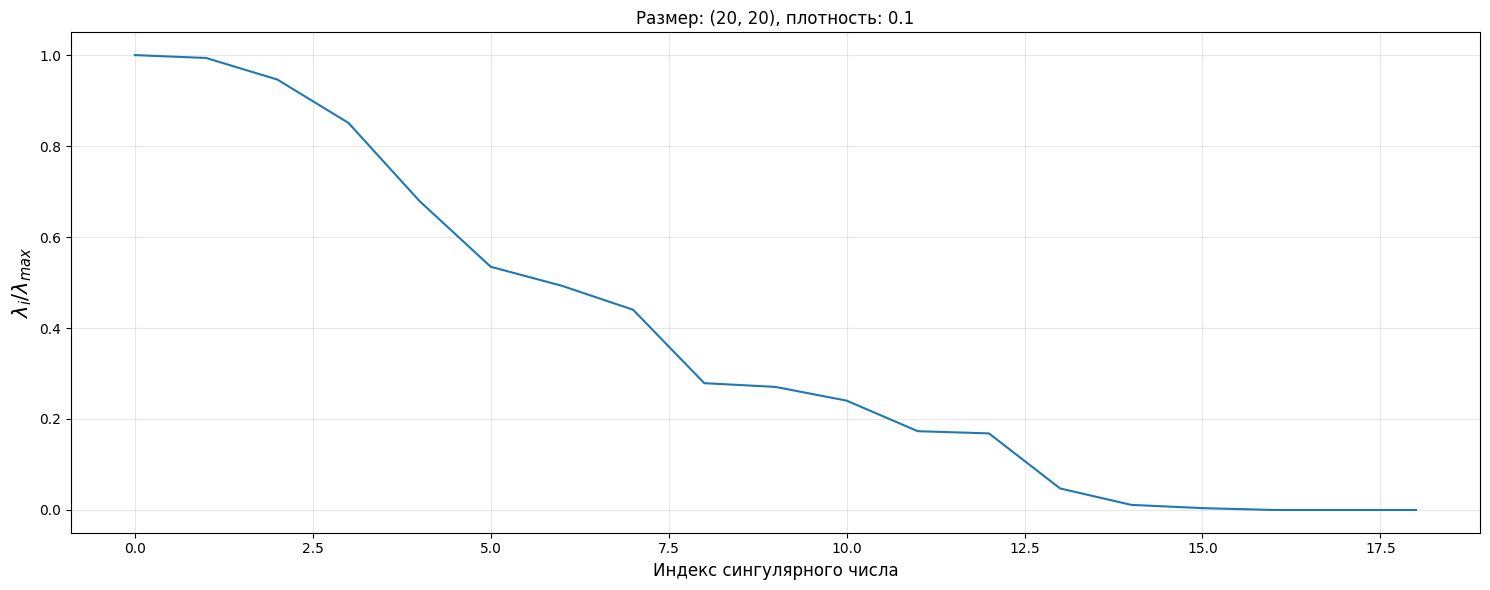

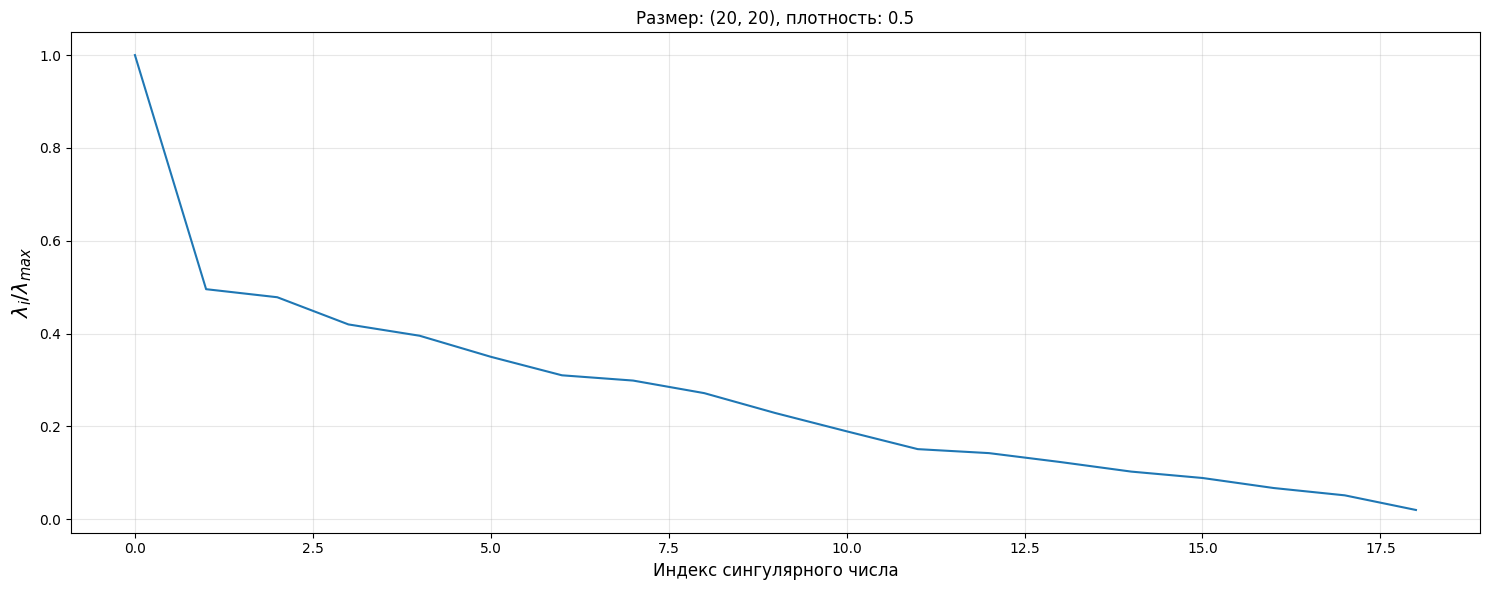

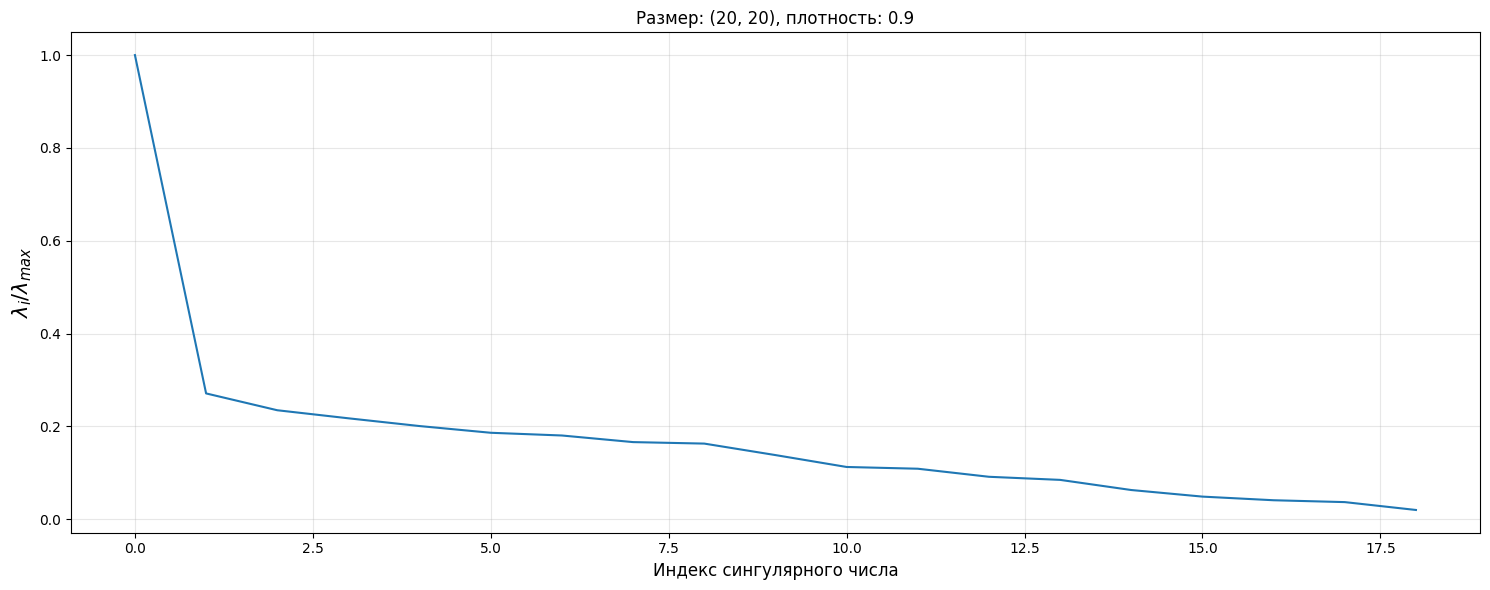

In [21]:
def singular_values_attenuation_in_sparse(shape, density):
    sing_values_sum = np.zeros(min(shape) - 1)
    sample_size = 100
    
    for _ in range(sample_size):
        sparse_mat = sparse.rand(shape[0], shape[1], density=density, random_state=42)
        sing_vals = svds(sparse_mat, k=min(shape)-1, return_singular_vectors=False)
        sing_values_sum += sing_vals
    
    plt.figure(figsize=(15, 6))
    plt.title(f'Размер: {shape}, плотность: {density}')
    plt.ylabel(r'$\lambda_i / \lambda_{max}$', fontsize=15)
    mean_vals = sing_values_sum[::-1] / sample_size
    plt.plot(mean_vals / mean_vals[0])
    plt.xlabel('Индекс сингулярного числа', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

size = 20
singular_values_attenuation_in_sparse((size, size), 0.1)
singular_values_attenuation_in_sparse((size, size), 0.5)
singular_values_attenuation_in_sparse((size, size), 0.9)


In [22]:
def pseudo_inverse_svd(A, threshold=1e-10):
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    
    s_inv = np.zeros_like(s)
    mask = s > threshold
    s_inv[mask] = 1.0 / s[mask]
    
    A_pinv = Vt.T @ np.diag(s_inv) @ U.T
    
    return A_pinv, s, np.linalg.cond(A)

def lstsq_svd(A, b, threshold=1e-10):
    A_pinv, s, cond = pseudo_inverse_svd(A, threshold)
    x = A_pinv @ b
    return x, cond

def lstsq_qr(A, b):
    Q, R = qr(A, mode='economic')
    y = Q.T @ b
    x = np.linalg.solve(R, y)
    return x

m_test, n_test = 50, 30
A_dense = np.random.randn(m_test, n_test)
b_test = np.random.randn(m_test)

x_svd, cond_svd = lstsq_svd(A_dense, b_test)
x_qr = lstsq_qr(A_dense, b_test)
x_numpy = np.linalg.lstsq(A_dense, b_test, rcond=None)[0]

print(f"Число обусловленности: {cond_svd:.2e}")
print(f"\nРазница между методами:")
print(f"SVD vs NumPy: {np.linalg.norm(x_svd - x_numpy):.2e}")
print(f"QR vs NumPy: {np.linalg.norm(x_qr - x_numpy):.2e}")
print(f"SVD vs QR: {np.linalg.norm(x_svd - x_qr):.2e}")
print(f"\nНормы невязок:")
print(f"SVD: {np.linalg.norm(A_dense @ x_svd - b_test):.2e}")
print(f"QR: {np.linalg.norm(A_dense @ x_qr - b_test):.2e}")
print(f"NumPy: {np.linalg.norm(A_dense @ x_numpy - b_test):.2e}")


Число обусловленности: 7.32e+00

Разница между методами:
SVD vs NumPy: 2.34e-15
QR vs NumPy: 2.91e-15
SVD vs QR: 3.30e-15

Нормы невязок:
SVD: 3.98e+00
QR: 3.98e+00
NumPy: 3.98e+00


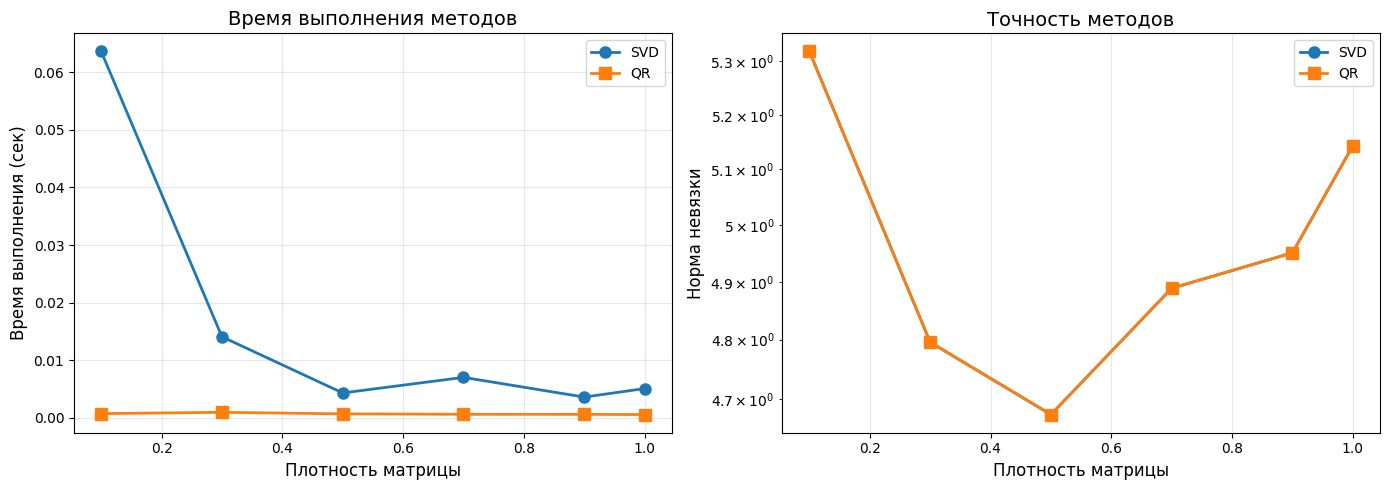

In [23]:
densities = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
m_comp, n_comp = 100, 80
results = {'density': [], 'svd_time': [], 'qr_time': [], 'svd_residual': [], 'qr_residual': []}

for density in densities:
    if density == 1.0:
        A_comp = np.random.randn(m_comp, n_comp)
    else:
        A_comp = sparse.rand(m_comp, n_comp, density=density, random_state=42).toarray()
    
    b_comp = np.random.randn(m_comp)
    
    start = time.time()
    x_svd_comp, _ = lstsq_svd(A_comp, b_comp)
    time_svd = time.time() - start
    
    start = time.time()
    x_qr_comp = lstsq_qr(A_comp, b_comp)
    time_qr = time.time() - start
    
    results['density'].append(density)
    results['svd_time'].append(time_svd)
    results['qr_time'].append(time_qr)
    results['svd_residual'].append(np.linalg.norm(A_comp @ x_svd_comp - b_comp))
    results['qr_residual'].append(np.linalg.norm(A_comp @ x_qr_comp - b_comp))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results['density'], results['svd_time'], 'o-', label='SVD', linewidth=2, markersize=8)
axes[0].plot(results['density'], results['qr_time'], 's-', label='QR', linewidth=2, markersize=8)
axes[0].set_xlabel('Плотность матрицы', fontsize=12)
axes[0].set_ylabel('Время выполнения (сек)', fontsize=12)
axes[0].set_title('Время выполнения методов', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(results['density'], results['svd_residual'], 'o-', label='SVD', linewidth=2, markersize=8)
axes[1].semilogy(results['density'], results['qr_residual'], 's-', label='QR', linewidth=2, markersize=8)
axes[1].set_xlabel('Плотность матрицы', fontsize=12)
axes[1].set_ylabel('Норма невязки', fontsize=12)
axes[1].set_title('Точность методов', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


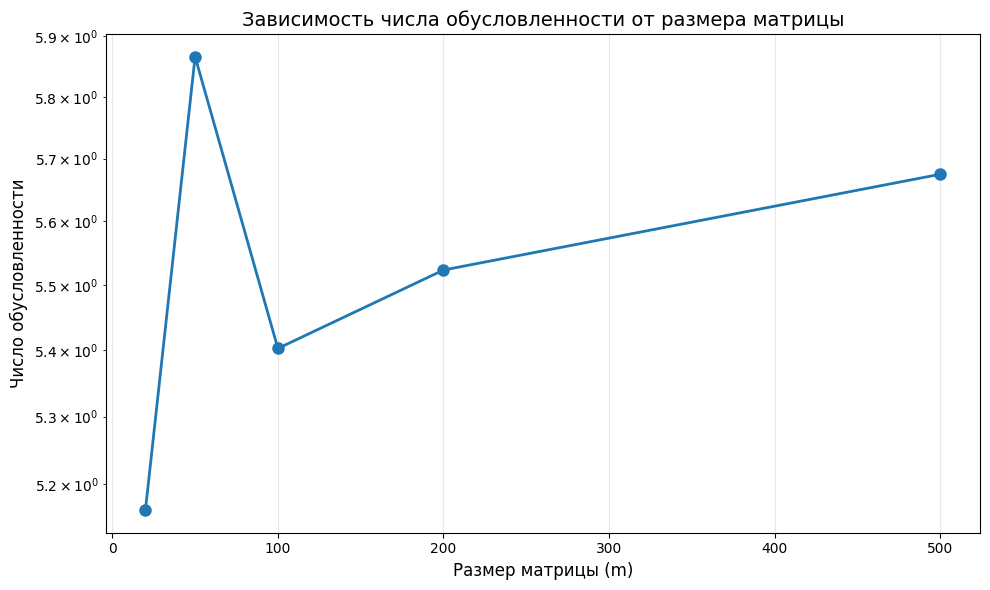

Исследование влияния порога на псевдообратную матрицу:
Порог 1e-12: сохранено 20/20 сингулярных чисел, норма невязки: 3.09e-14
Порог 1e-10: сохранено 20/20 сингулярных чисел, норма невязки: 3.09e-14
Порог 1e-08: сохранено 20/20 сингулярных чисел, норма невязки: 3.09e-14
Порог 1e-06: сохранено 20/20 сингулярных чисел, норма невязки: 3.09e-14
Порог 1e-04: сохранено 20/20 сингулярных чисел, норма невязки: 3.09e-14


In [24]:
sizes = [20, 50, 100, 200, 500]
thresholds = [1e-12, 1e-10, 1e-8, 1e-6, 1e-4]
condition_numbers = []

for size in sizes:
    A_cond = np.random.randn(size, size//2)
    A_cond = A_cond + 0.01 * np.random.randn(size, size//2)
    _, _, cond = pseudo_inverse_svd(A_cond)
    condition_numbers.append(cond)

plt.figure(figsize=(10, 6))
plt.semilogy(sizes, condition_numbers, 'o-', linewidth=2, markersize=8)
plt.xlabel('Размер матрицы (m)', fontsize=12)
plt.ylabel('Число обусловленности', fontsize=12)
plt.title('Зависимость числа обусловленности от размера матрицы', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Исследование влияния порога на псевдообратную матрицу:")
A_test_cond = np.random.randn(30, 20)
U_test, s_test, Vt_test = np.linalg.svd(A_test_cond, full_matrices=False)

for threshold in thresholds:
    s_inv_test = np.zeros_like(s_test)
    mask = s_test > threshold
    s_inv_test[mask] = 1.0 / s_test[mask]
    A_pinv_test = Vt_test.T @ np.diag(s_inv_test) @ U_test.T
    
    num_kept = np.sum(mask)
    residual = np.linalg.norm(A_test_cond @ A_pinv_test @ A_test_cond - A_test_cond)
    print(f"Порог {threshold:.0e}: сохранено {num_kept}/{len(s_test)} сингулярных чисел, "
          f"норма невязки: {residual:.2e}")
